# Portfolio Return Calculator
### CFA Level 1 Quantitative Methods - Applied Project
### Started: May 2026

Fetching live prices...

Ticker  Shares  Buy Price   Live Price  Total Cost  Mkt Value   G/L $     HPR
------------------------------------------------------------------------------------------
SPY     5       $717.84     $754.83     $3,589.20   $3,774.15   $184.95   5.1530%
JPM     5       $308.23     $319.40     $1,541.15   $1,597.00   $55.85    3.6239%
BAC     5       $52.29      $55.87      $261.45     $279.35     $17.90    6.8464%
C       5       $125.0      $141.21     $625.00     $706.05     $81.05    12.9680%
ABT     5       $84.44      $88.67      $422.20     $443.35     $21.15    5.0095%
HON     5       $215.28     $227.41     $1,076.40   $1,137.05   $60.65    5.6345%
MRNA    5       $58.08      $52.13      $290.40     $260.65     $-29.75   -10.2445%
TMO     5       $464.86     $473.72     $2,324.30   $2,368.60   $44.30    1.9060%
IONQ    5       $61.4       $61.18      $307.00     $305.90     $-1.10    -0.3583%


/tmp/ipykernel_6289/1022420928.py:100: FutureWarning: YF.download() has changed argument auto_adjust default to True
  spy = yf.download("SPY", start="2026-05-06", end="2026-06-17")["Close"].squeeze()
[*********************100%***********************]  1 of 1 completed

PLTR    5       $130.02     $134.71     $650.10     $673.55     $23.45    3.6071%
------------------------------------------------------------------------------------------

Starting Capital:      $  100,000.00
Total Invested:        $   11,087.20
Cash Remaining:        $   88,879.25
Total Mkt Value:       $   11,545.65
Total Portfolio Value: $  100,424.90
Total Gain/Loss:       $      424.90
Portfolio Return:           0.4249%


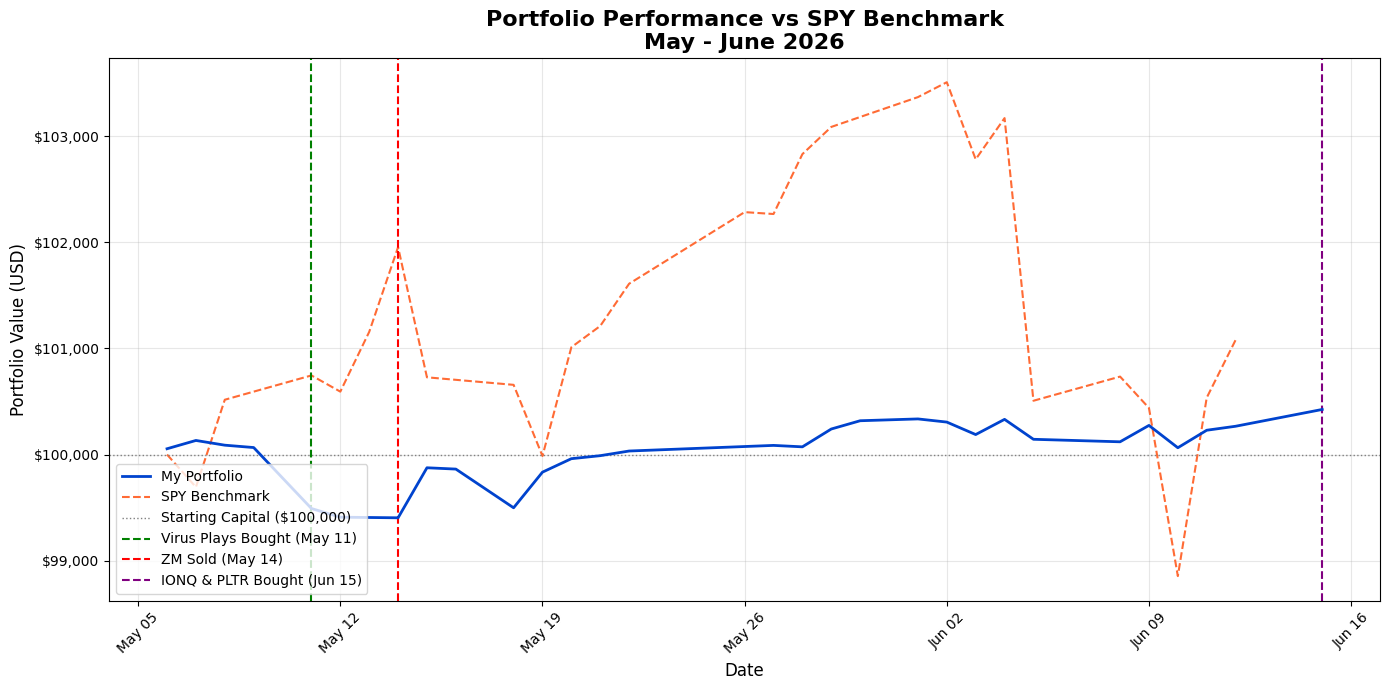

Chart saved!


In [3]:
!pip install yfinance --quiet

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ============================================
# SECTION 1: Current Portfolio Snapshot
# ============================================

starting_capital = 100000

trades = [
    {"ticker": "SPY",  "shares": 5, "purchase_price": 717.84},
    {"ticker": "JPM",  "shares": 5, "purchase_price": 308.23},
    {"ticker": "BAC",  "shares": 5, "purchase_price": 52.29},
    {"ticker": "C",    "shares": 5, "purchase_price": 125.00},
    # ZM bought 2026-05-11, sold 2026-05-14 at $102.58, realized loss: -$33.55
    {"ticker": "ABT",  "shares": 5, "purchase_price": 84.44},
    {"ticker": "HON",  "shares": 5, "purchase_price": 215.28},
    {"ticker": "MRNA", "shares": 5, "purchase_price": 58.08},
    {"ticker": "TMO",  "shares": 5, "purchase_price": 464.86},
    {"ticker": "IONQ", "shares": 5, "purchase_price": 61.40},
    {"ticker": "PLTR", "shares": 5, "purchase_price": 130.02},
]

zm_realized_loss = -33.55  # locked in when ZM was sold

print("Fetching live prices...\n")

total_cost = 0
total_market_value = 0

print(f"{'Ticker':<8}{'Shares':<8}{'Buy Price':<12}{'Live Price':<12}{'Total Cost':<12}{'Mkt Value':<12}{'G/L $':<10}{'HPR'}")
print("-" * 90)

for trade in trades:
    stock = yf.Ticker(trade["ticker"])
    live_price = stock.fast_info["last_price"]

    tc = trade["shares"] * trade["purchase_price"]
    mv = trade["shares"] * live_price
    gl = mv - tc
    hpr = gl / tc

    total_cost += tc
    total_market_value += mv

    print(f"{trade['ticker']:<8}{trade['shares']:<8}${trade['purchase_price']:<11}${live_price:<11.2f}${tc:<11,.2f}${mv:<11,.2f}${gl:<9,.2f}{hpr:.4%}")

print("-" * 90)

cash_remaining = starting_capital - total_cost + zm_realized_loss
total_portfolio_value = total_market_value + cash_remaining
total_gl = total_portfolio_value - starting_capital
portfolio_return = total_gl / starting_capital

print(f"\nStarting Capital:      ${starting_capital:>12,.2f}")
print(f"Total Invested:        ${total_cost:>12,.2f}")
print(f"Cash Remaining:        ${cash_remaining:>12,.2f}")
print(f"Total Mkt Value:       ${total_market_value:>12,.2f}")
print(f"Total Portfolio Value: ${total_portfolio_value:>12,.2f}")
print(f"Total Gain/Loss:       ${total_gl:>12,.2f}")
print(f"Portfolio Return:      {portfolio_return:>12.4%}")


# ============================================
# SECTION 2: Portfolio Performance Chart
# ============================================

# Historical portfolio value, manually logged from Trading Journal "Price History" sheet
history = {
    "Date": [
        "2026-05-06", "2026-05-07", "2026-05-08", "2026-05-09",
        "2026-05-11", "2026-05-12", "2026-05-14", "2026-05-15",
        "2026-05-16", "2026-05-18", "2026-05-19", "2026-05-20",
        "2026-05-21", "2026-05-22", "2026-05-27", "2026-05-28",
        "2026-05-29", "2026-05-30", "2026-06-01", "2026-06-02",
        "2026-06-03", "2026-06-04", "2026-06-05", "2026-06-08",
        "2026-06-09", "2026-06-10", "2026-06-11", "2026-06-12",
        "2026-06-15"
    ],
    "Portfolio_Value": [
        100054.70, 100132.85, 100088.35, 100066.10,
        99491.85, 99410.00, 99404.20, 99875.55,
        99863.20, 99498.55, 99834.35, 99961.15,
        99989.50, 100033.35, 100086.30, 100072.75,
        100240.70, 100318.60, 100335.70, 100305.95,
        100188.40, 100331.65, 100143.85, 100120.20,
        100274.60, 100064.21, 100229.10, 100266.65,
        100424.90
    ]
}

df = pd.DataFrame(history)
df["Date"] = pd.to_datetime(df["Date"])

# SPY benchmark, normalized to same $100,000 starting base
spy = yf.download("SPY", start="2026-05-06", end="2026-06-17")["Close"].squeeze()
spy_normalized = (spy / spy.iloc[0]) * starting_capital

fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(df["Date"], df["Portfolio_Value"],
        color="#0043CE", linewidth=2, label="My Portfolio", zorder=3)

ax.plot(spy_normalized.index, spy_normalized.values,
        color="#FF6B35", linewidth=1.5, linestyle="--", label="SPY Benchmark", zorder=2)

ax.axhline(y=starting_capital, color="gray", linewidth=1, linestyle=":",
           label=f"Starting Capital (${starting_capital:,.0f})")

ax.axvline(pd.Timestamp("2026-05-11"), color="green", linewidth=1.5,
           linestyle="--", label="Virus Plays Bought (May 11)")
ax.axvline(pd.Timestamp("2026-05-14"), color="red", linewidth=1.5,
           linestyle="--", label="ZM Sold (May 14)")
ax.axvline(pd.Timestamp("2026-06-15"), color="purple", linewidth=1.5,
           linestyle="--", label="IONQ & PLTR Bought (Jun 15)")

ax.set_title("Portfolio Performance vs SPY Benchmark\nMay - June 2026",
              fontsize=16, fontweight="bold")
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Portfolio Value (USD)", fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"${x:,.0f}"))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
ax.legend(loc="lower left")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("portfolio_performance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved!")